In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import xgboost 
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, 
    roc_curve, precision_recall_curve, make_scorer,RocCurveDisplay
)

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


In [40]:

df = pd.read_csv('Dataset/data_merged.csv')



In [41]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

df_processed['duration_ms'] = df_processed['duration_ms']/60000



# 1. Variable binaria (popular vs no popular)
# la mediana como punto de corte
popularity_median = df_processed['popularity'].median()
print(f"   - Mediana de popularidad: {popularity_median}")
df_processed['is_popular_binary'] = (df_processed['popularity'] > popularity_median).astype(int)

# 2. Variable multiclase (3 niveles: Baja, Media, Alta)
# Usar terciles para dividir en 3 categorías
terciles = df_processed['popularity'].quantile([0.33, 0.67])
print(f"   - Terciles de popularidad: {terciles.values}")

def categorize_popularity(popularity):
    if popularity <= terciles[0.33]:
        return 0  # Baja
    elif popularity <= terciles[0.67]:
        return 1  # Media
    else:
        return 2  # Alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)

# 3. Variable multiclase (5 niveles: Muy Baja, Baja, Media, Alta, Muy Alta)
quintiles = df_processed['popularity'].quantile([0.2, 0.4, 0.6, 0.8])
print(f"   - Quintiles de popularidad: {quintiles.values}")

def categorize_popularity_5levels(popularity):
    if popularity <= quintiles[0.2]:
        return 0  # Muy Baja
    elif popularity <= quintiles[0.4]:
        return 1  # Baja
    elif popularity <= quintiles[0.6]:
        return 2  # Media
    elif popularity <= quintiles[0.8]:
        return 3  # Alta
    else:
        return 4  # Muy Alta

df_processed['popularity_5levels'] = df_processed['popularity'].apply(categorize_popularity_5levels)

print("Variable binaria (is_popular_binary):")
print(df_processed['is_popular_binary'].value_counts().sort_index())
print(f"   Proporción: {df_processed['is_popular_binary'].mean():.3f}")

print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")

print("\nVariable multiclase 5 niveles (popularity_5levels):")
fiveclass_counts = df_processed['popularity_5levels'].value_counts().sort_index()
fiveclass_labels = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
for i, (count, label) in enumerate(zip(fiveclass_counts, fiveclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")

print(f"\n✅ Preprocesamiento completado")
print(f"📊 Dataset final: {df_processed.shape[0]} filas, {df_processed.shape[1]} columnas")

   - Mediana de popularidad: 26.0
   - Terciles de popularidad: [ 9. 37.]
   - Quintiles de popularidad: [ 0. 17. 32. 46.]
Variable binaria (is_popular_binary):
is_popular_binary
0    88034
1    84196
Name: count, dtype: int64
   Proporción: 0.489

Variable multiclase 3 niveles (popularity_multiclass):
   0 (Baja): 57080 (33.1%)
   1 (Media): 60091 (34.9%)
   2 (Alta): 55059 (32.0%)

Variable multiclase 5 niveles (popularity_5levels):
   0 (Muy Baja): 39729 (23.1%)
   1 (Baja): 29179 (16.9%)
   2 (Media): 34591 (20.1%)
   3 (Alta): 34303 (19.9%)
   4 (Muy Alta): 34428 (20.0%)

✅ Preprocesamiento completado
📊 Dataset final: 172230 filas, 75 columnas


In [ ]:
scaler = RobustScaler()
scaler1 = RobustScaler()
scaler2 = RobustScaler()
_X = df_processed.copy()
pca = PCA(n_components=0.95)
X = _X.drop(columns=['popularity','popularity_multiclass','is_popular_binary','popularity_5levels'])
y_binary = df_processed['is_popular_binary']
y_multiclass_3 = df_processed['popularity_multiclass'] 
y_multiclass_5 = df_processed['popularity_5levels']


test_size = 0.2
random_state = 42

# División para clasificación binaria
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, 
    test_size=test_size, 
    stratify=y_binary,
    random_state=random_state
)
X_train_bin = scaler.fit_transform(X_train_bin)
X_train_bin = pca.fit_transform(X_train_bin)
# División para clasificación multiclase (3)
X_train_multi3, X_test_multi3, y_train_multi3, y_test_multi3 = train_test_split(
    X, y_multiclass_3, 
    test_size=test_size, 
    stratify=y_multiclass_3,
    random_state=random_state
)
X_train_multi3 = scaler1.fit_transform(X_train_multi3)
X_train_multi3 = pca.fit_transform(X_train_multi3)
# División para clasificación multiclase (5)
X_train_multi5, X_test_multi5, y_train_multi5, y_test_multi5 = train_test_split(
    X, y_multiclass_5, 
    test_size=test_size, 
    stratify=y_multiclass_5,
    random_state=random_state
)
X_train_multi5= scaler2.fit_transform(X_train_multi5)
X_train_multi5 = pca.fit_transform(X_train_multi5)


In [ ]:
import time
base_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1
    ),
    
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10
    ),
    
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'
    ),
    
    'Naive Bayes': GaussianNB(),
    
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100,
        n_jobs=-1
    ),
}

param_grids = {
   
    'Logistic Regression': {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5, 10]
    },
    'Gradient Boosting': {
        'n_estimators': [ 100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [ 5, 7]
    },
    'Decision Tree': {
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy']
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Extra Trees': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5, 10]
    }
}


Grid Search para Logistic Regression...
{'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
   Completado - F1: 0.8924, Mejores params: {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
Grid Search para Random Forest...
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
   Completado - F1: 0.9105, Mejores params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Grid Search para Gradient Boosting...
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
   Completado - F1: 0.9084, Mejores params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Grid Search para Decision Tree...
{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
   Completado - F1: 0.9024, Mejores params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Grid Search para K-Nearest Neighbors...
{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
   Completado - F1: 0.8992, Mejores params: {'metric': 'manhattan', 'n_neighbors': 9, 'weigh

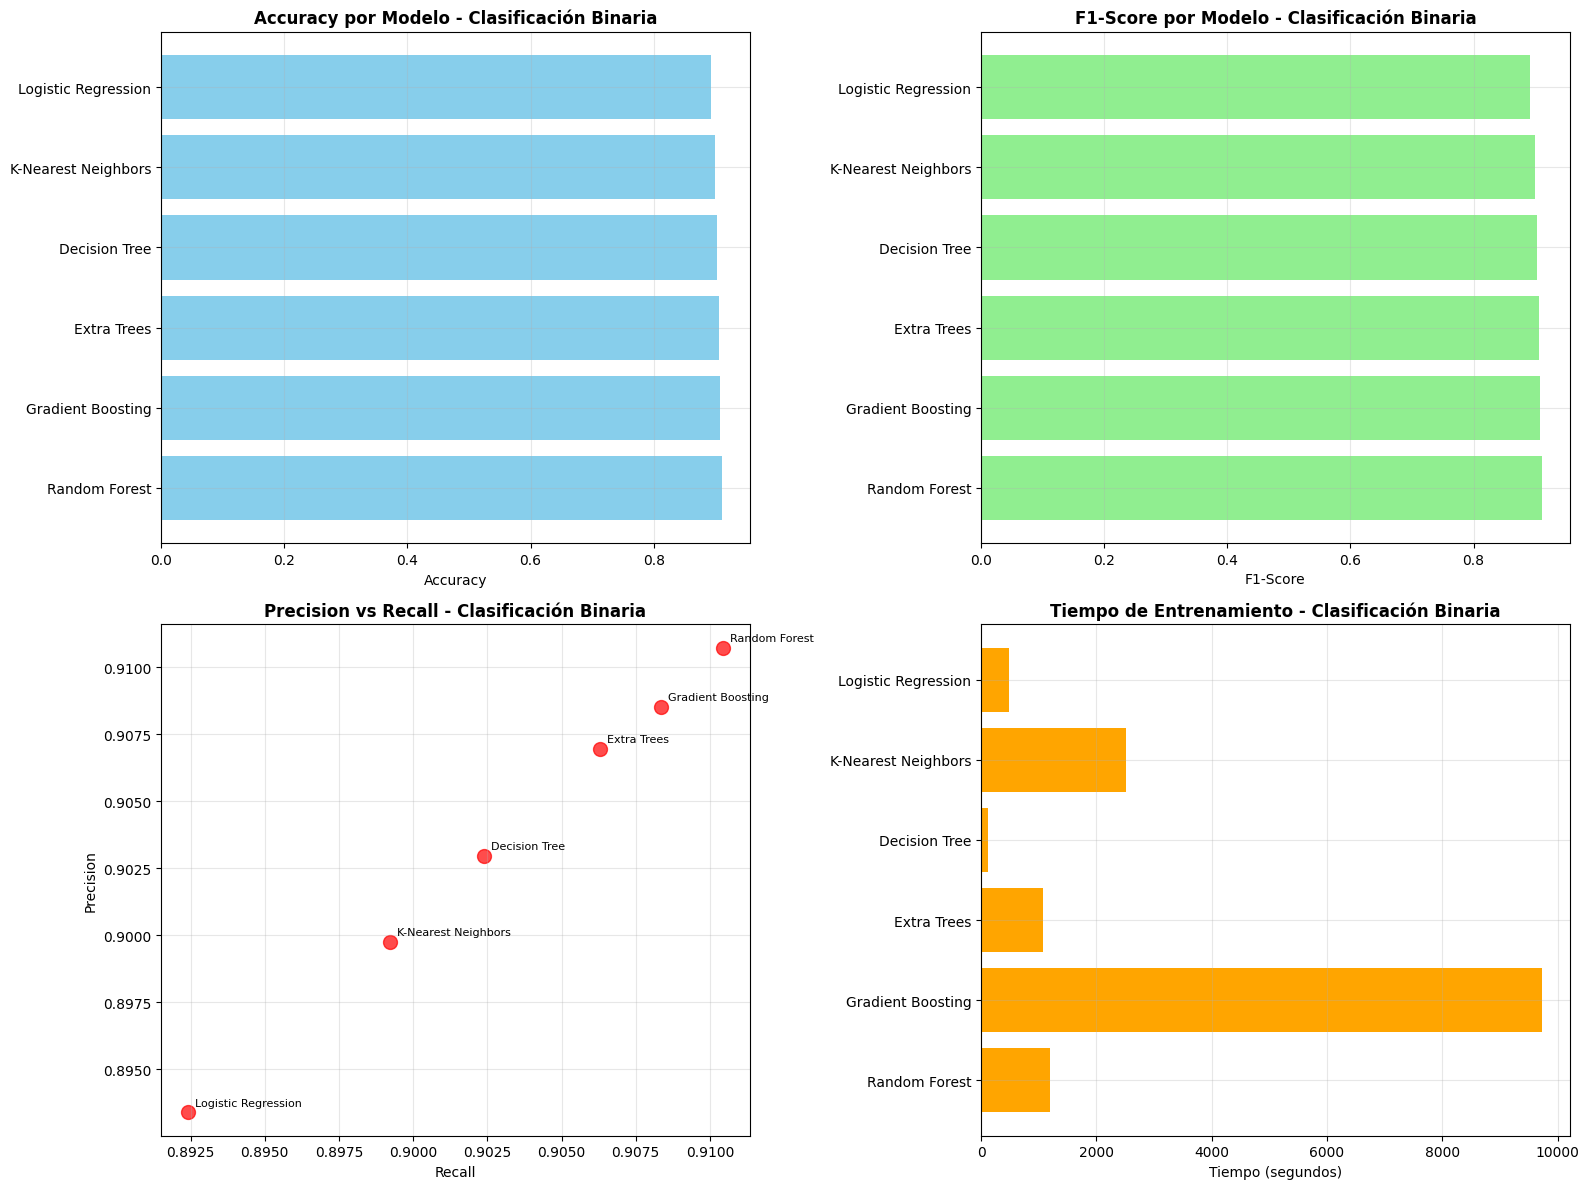

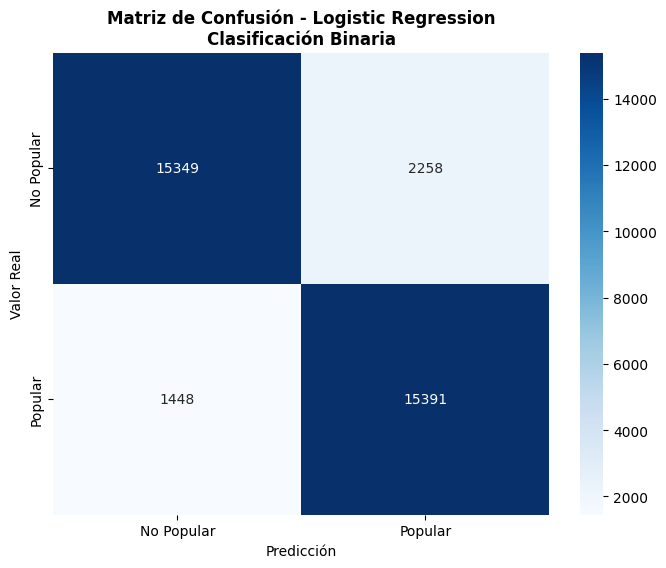

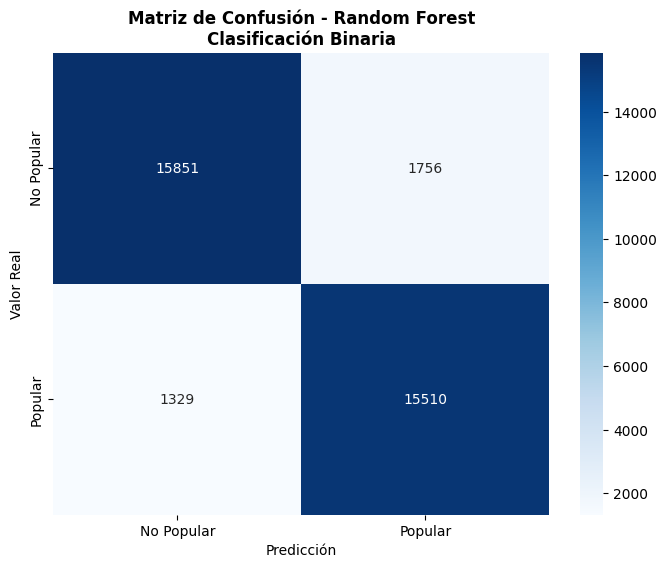

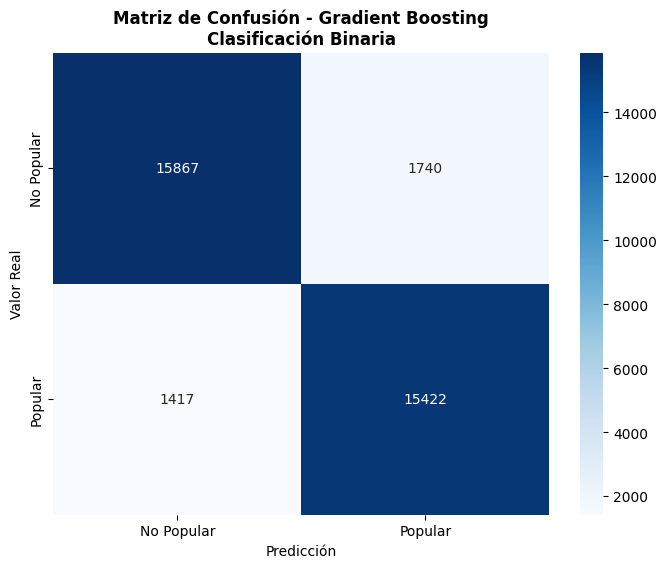

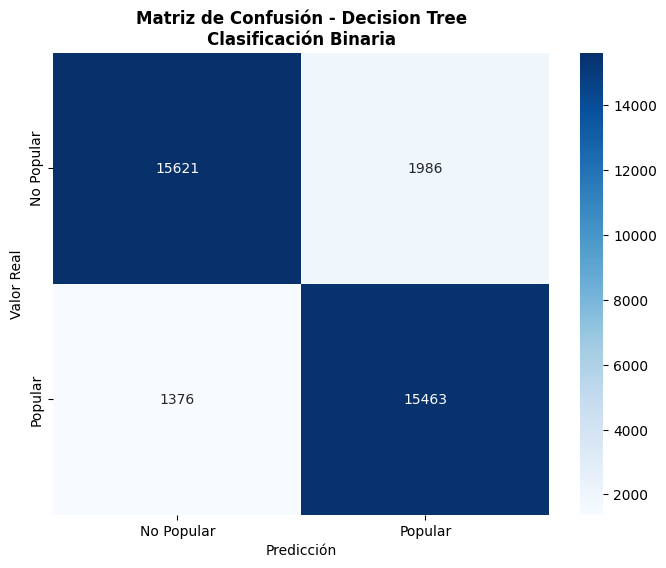

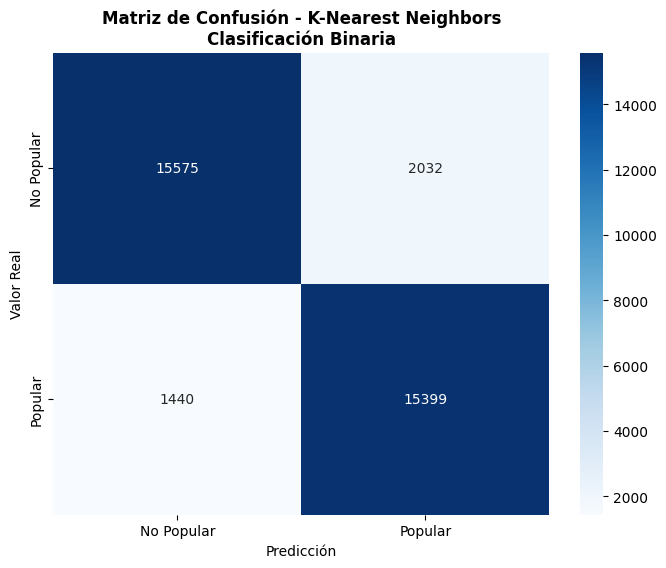

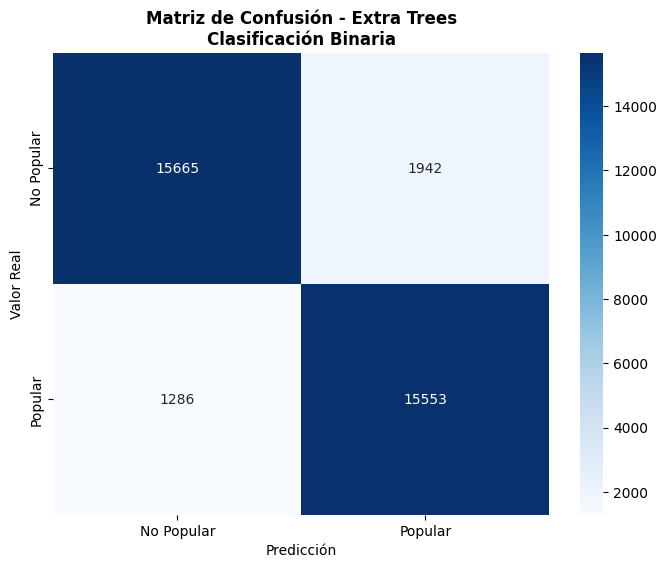


Clasificación binaria completada con 6 modelos


In [ ]:
# CLASIFICACIÓN BINARIA 

def grid_search_model(model, param_grid, X_train, X_test, y_train, y_test, model_name, _scaler,cv=5,pca = pca):
    print(f"Grid Search para {model_name}...")
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=0
    )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    best_model = grid_search.best_estimator_
    print(grid_search.best_params_)
    X_test = _scaler.transform(X_test)
    X_test = pca.transform(X_test)
    y_pred = best_model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results = {
        'model_name': model_name,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'training_time': training_time,
        'model_object': best_model,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    
    print(f"   Completado - F1: {f1:.4f}, Mejores params: {grid_search.best_params_}")
    return results

binary_grid_results = []


for model_name, model in base_models.items():
    try:
        if model_name in param_grids:
            result = grid_search_model(
                model=model,
                param_grid=param_grids[model_name],
                X_train=X_train_bin,
                X_test=X_test_bin,
                y_train=y_train_bin,
                y_test=y_test_bin,
                model_name=model_name,
                _scaler=scaler,
                pca=pca
            )
            binary_grid_results.append(result)
    except Exception as e:
        print(f"Error con {model_name}: {str(e)}")

binary_grid_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'CV Score': r['best_score'],
    'Tiempo (s)': r['training_time']
} for r in binary_grid_results])

binary_grid_df = binary_grid_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print("RESULTADOS GRID SEARCH - CLASIFICACIÓN BINARIA:")
print(binary_grid_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].barh(binary_grid_df['Modelo'], binary_grid_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Clasificación Binaria', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].barh(binary_grid_df['Modelo'], binary_grid_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Clasificación Binaria', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(binary_grid_df['Recall'], binary_grid_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(binary_grid_df['Modelo']):
    axes[1,0].annotate(txt, (binary_grid_df['Recall'].iloc[i], binary_grid_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Clasificación Binaria', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(binary_grid_df['Modelo'], binary_grid_df['Tiempo (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Clasificación Binaria', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


for i,_ in enumerate(binary_grid_results):
    plt.figure(figsize=(8, 6))
    cm = binary_grid_results[i]['confusion_matrix']
    name = binary_grid_results[i]['model_name']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'Popular'],
                yticklabels=['No Popular', 'Popular'])
    plt.title(f'Matriz de Confusión - {name}\nClasificación Binaria', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

print(f"\nClasificación binaria completada con {len(binary_grid_results)} modelos")

Grid Search para Random Forest...
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
   Completado - F1: 0.8526, Mejores params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Grid Search para Gradient Boosting...
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
   Completado - F1: 0.8506, Mejores params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Grid Search para Decision Tree...
{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10}
   Completado - F1: 0.8362, Mejores params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10}
Grid Search para K-Nearest Neighbors...
{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
   Completado - F1: 0.8234, Mejores params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Grid Search para Extra Trees...
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
   Completado - F1: 0.8433, Mejores params: {'max_depth': None, 'min_sam

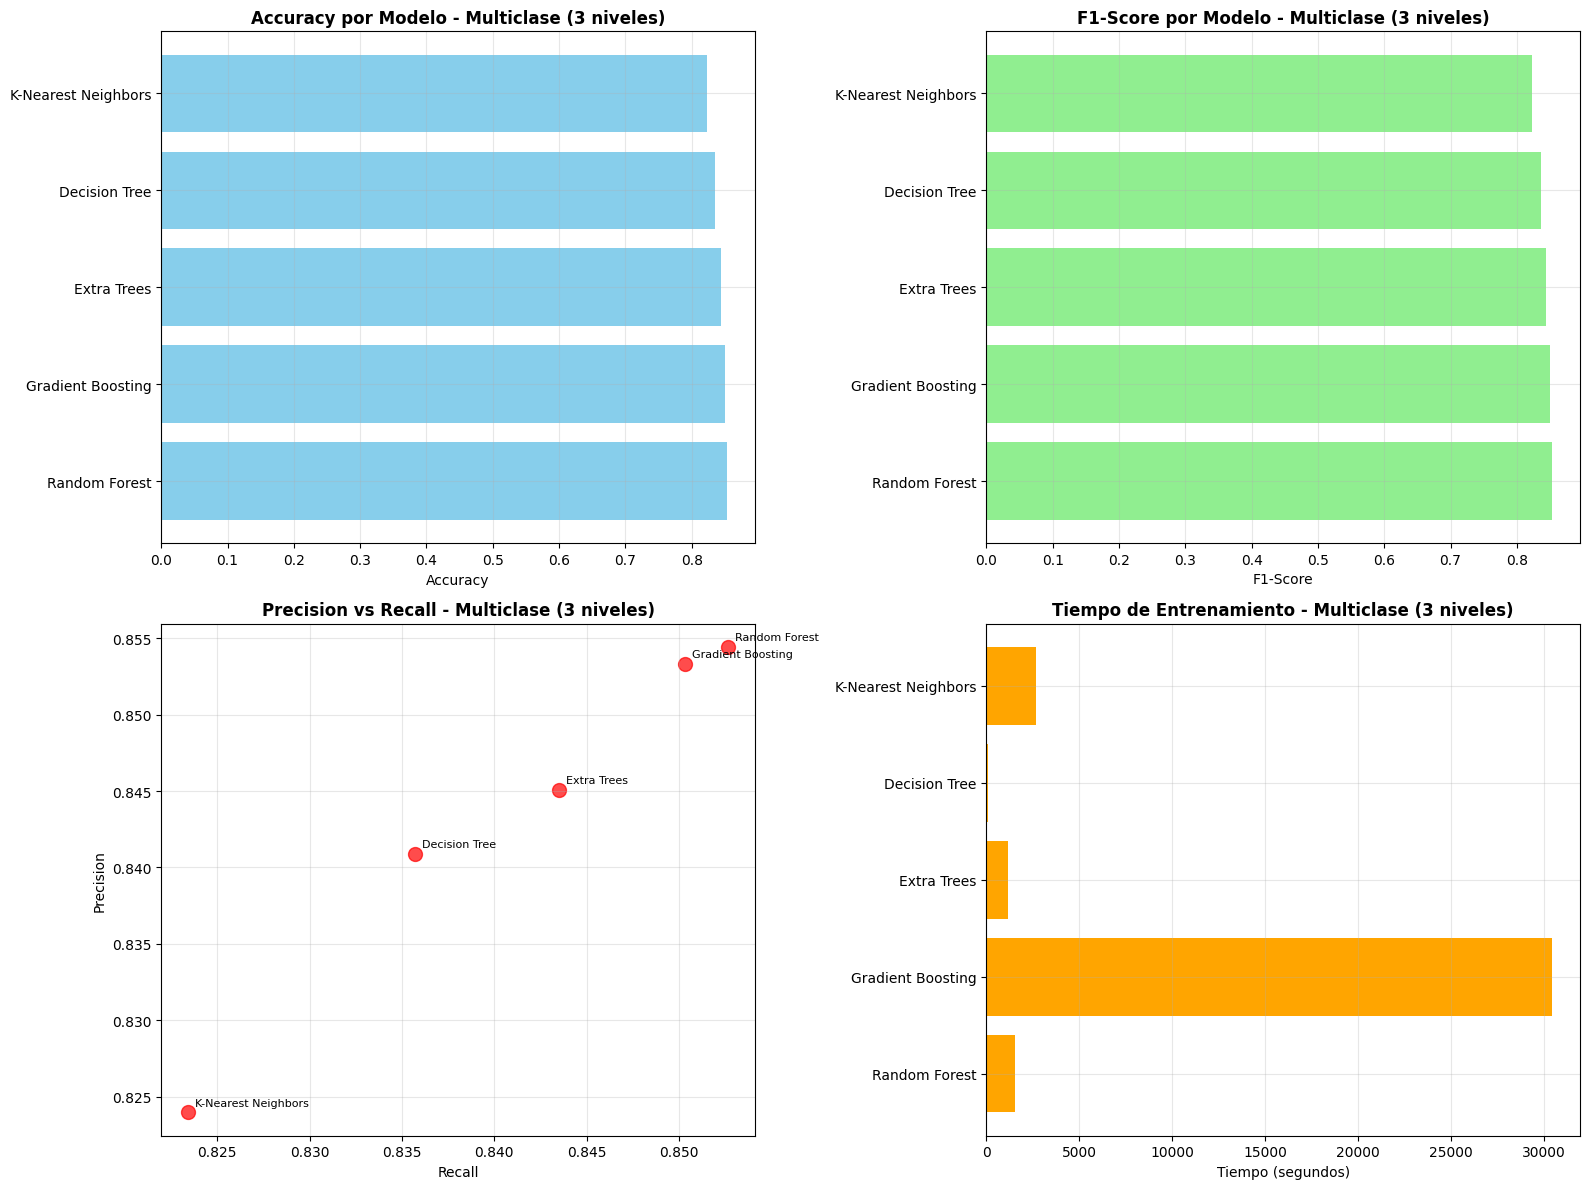

              precision    recall  f1-score   support

        Baja     0.9441    0.9533    0.9487     11416
       Media     0.7713    0.8285    0.7989     12018
        Alta     0.8521    0.7746    0.8115     11012

    accuracy                         0.8526     34446
   macro avg     0.8559    0.8521    0.8530     34446
weighted avg     0.8544    0.8526    0.8526     34446



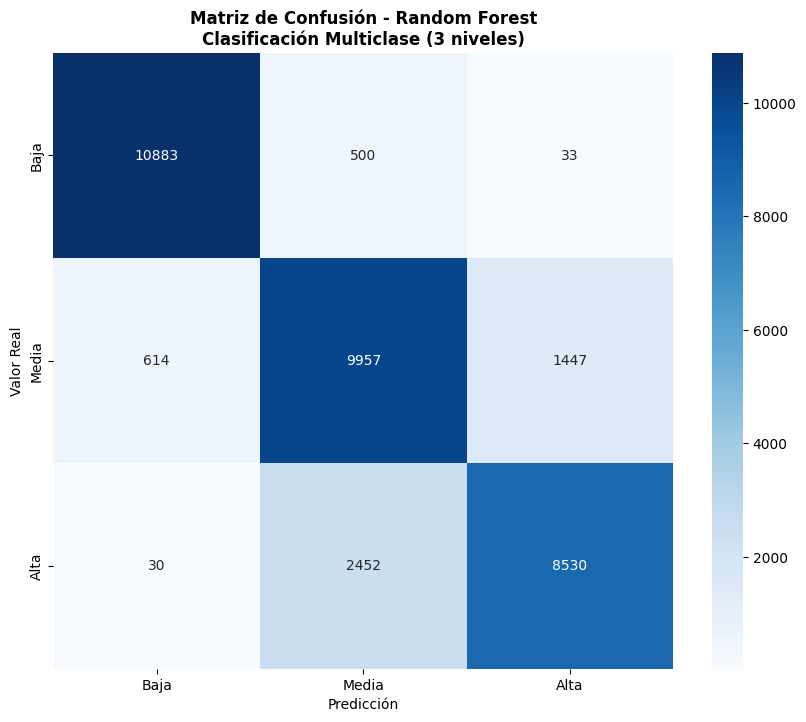

              precision    recall  f1-score   support

        Baja     0.9482    0.9464    0.9473     11416
       Media     0.7631    0.8341    0.7970     12018
        Alta     0.8534    0.7684    0.8087     11012

    accuracy                         0.8503     34446
   macro avg     0.8549    0.8496    0.8510     34446
weighted avg     0.8533    0.8503    0.8506     34446



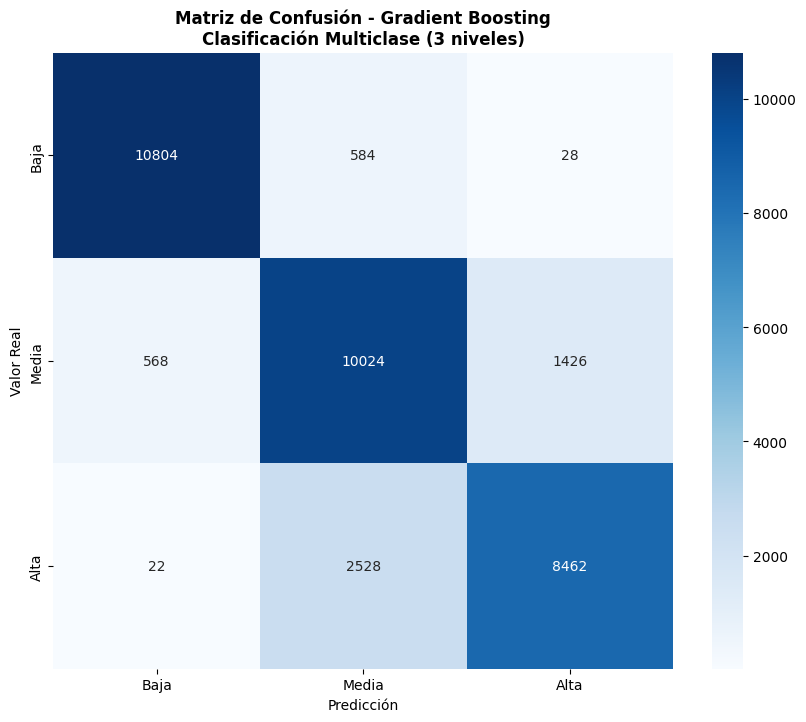

              precision    recall  f1-score   support

        Baja     0.9434    0.9304    0.9368     11416
       Media     0.7380    0.8307    0.7816     12018
        Alta     0.8469    0.7430    0.7916     11012

    accuracy                         0.8357     34446
   macro avg     0.8428    0.8347    0.8367     34446
weighted avg     0.8409    0.8357    0.8362     34446



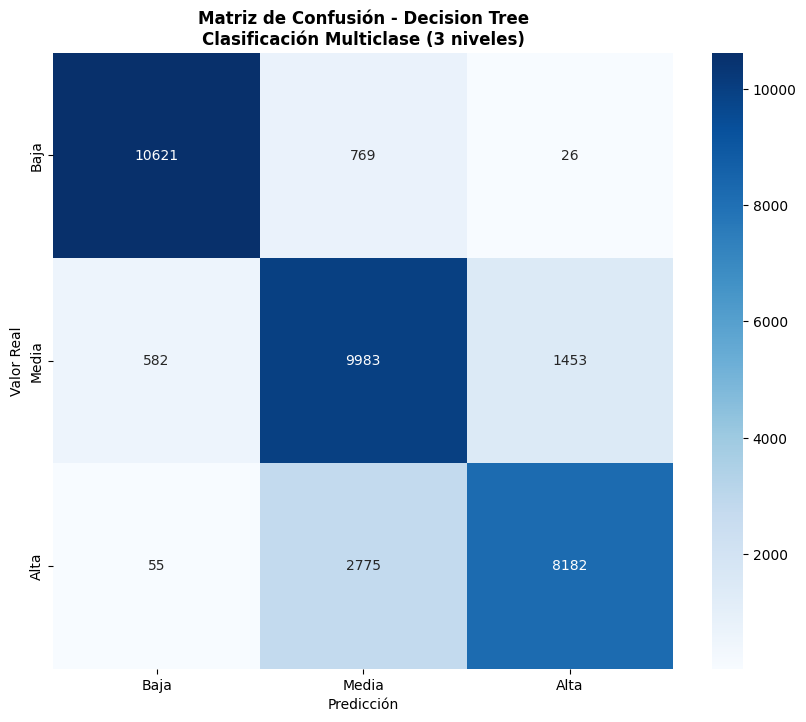

              precision    recall  f1-score   support

        Baja     0.9284    0.9359    0.9321     11416
       Media     0.7453    0.7781    0.7614     12018
        Alta     0.8015    0.7564    0.7783     11012

    accuracy                         0.8234     34446
   macro avg     0.8251    0.8234    0.8239     34446
weighted avg     0.8240    0.8234    0.8234     34446



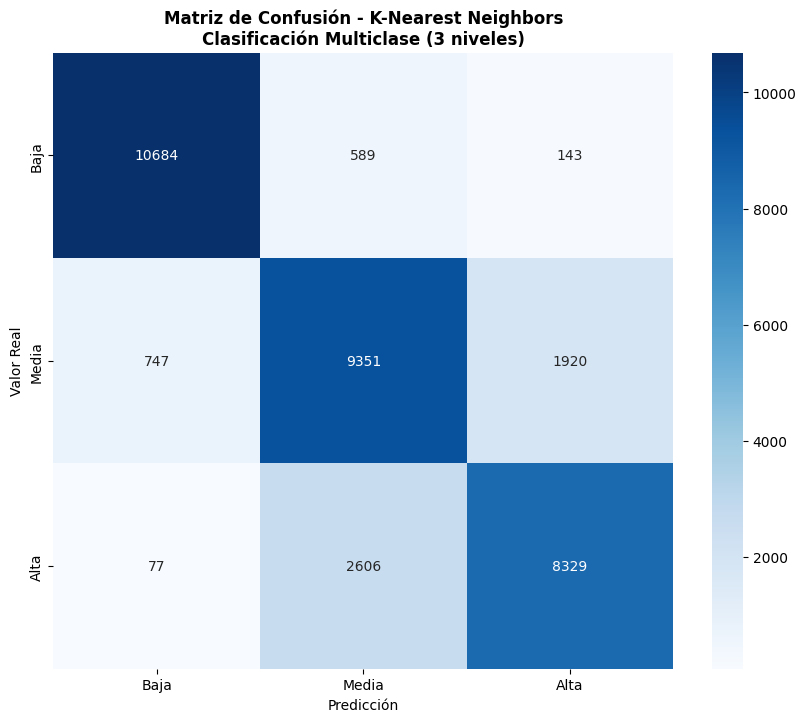

              precision    recall  f1-score   support

        Baja     0.9384    0.9525    0.9454     11416
       Media     0.7600    0.8145    0.7863     12018
        Alta     0.8412    0.7622    0.7998     11012

    accuracy                         0.8435     34446
   macro avg     0.8465    0.8431    0.8438     34446
weighted avg     0.8451    0.8435    0.8433     34446



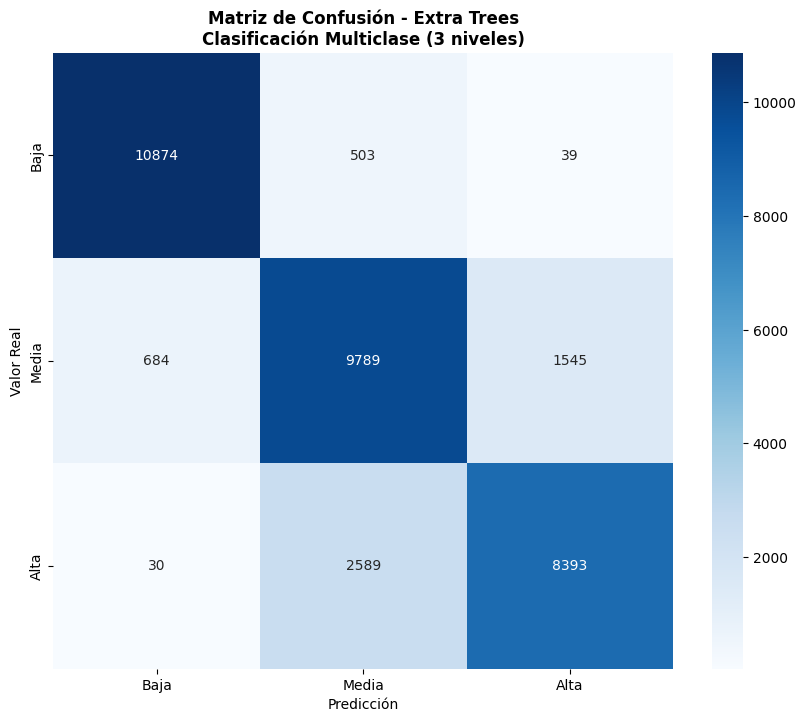


Clasificación multiclase (3 niveles) completada con 5 modelos


In [ ]:
# CLASIFICACIÓN MULTICLASE (3 NIVELES) 

multiclass3_grid_results = []

for model_name, model in base_models.items():
    try:
        if model_name == 'Logistic Regression' or model_name=='Naive Bayes':
            continue
      
        result = grid_search_model(
                model=model,
                param_grid=param_grids[model_name],
                X_train=X_train_multi3,
                X_test=X_test_multi3,
                y_train=y_train_multi3,
                y_test=y_test_multi3,
                model_name=model_name,
                _scaler=scaler1,
                pca=pca
            )
        multiclass3_grid_results.append(result)
    except Exception as e:
        print(f"Error con {model_name}: {str(e)}")

multiclass3_grid_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'CV Score': r['best_score'],
    'Tiempo (s)': r['training_time']
} for r in multiclass3_grid_results])

multiclass3_grid_df = multiclass3_grid_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print("RESULTADOS GRID SEARCH - CLASIFICACIÓN MULTICLASE (3 NIVELES):")
print(multiclass3_grid_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].barh(multiclass3_grid_df['Modelo'], multiclass3_grid_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (3 niveles)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].barh(multiclass3_grid_df['Modelo'], multiclass3_grid_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (3 niveles)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(multiclass3_grid_df['Recall'], multiclass3_grid_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(multiclass3_grid_df['Modelo']):
    axes[1,0].annotate(txt, (multiclass3_grid_df['Recall'].iloc[i], multiclass3_grid_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (3 niveles)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(multiclass3_grid_df['Modelo'], multiclass3_grid_df['Tiempo (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (3 niveles)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(multiclass3_grid_results):
    plt.figure(figsize=(10, 8))
    cm = multiclass3_grid_results[i]['confusion_matrix']
    _name = multiclass3_grid_results[i]['model_name']
    class_names = ['Baja', 'Media', 'Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'Matriz de Confusión - {_name}\nClasificación Multiclase (3 niveles)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi3, multiclass3_grid_results[i]['predictions'], 
                             target_names=class_names, digits=4)
    print(report)
    plt.show()



print(f"\nClasificación multiclase (3 niveles) completada con {len(multiclass3_grid_results)} modelos")

Grid Search para Logistic Regression...
{'C': 10.0, 'penalty': 'l1', 'solver': 'saga'}
   Completado - F1: 0.6868, Mejores params: {'C': 10.0, 'penalty': 'l1', 'solver': 'saga'}
Grid Search para Random Forest...
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
   Completado - F1: 0.7543, Mejores params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Grid Search para Gradient Boosting...
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
   Completado - F1: 0.7493, Mejores params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
Grid Search para Decision Tree...
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}
   Completado - F1: 0.7283, Mejores params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}
Grid Search para K-Nearest Neighbors...
{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
   Completado - F1: 0.6996, Mejores params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights

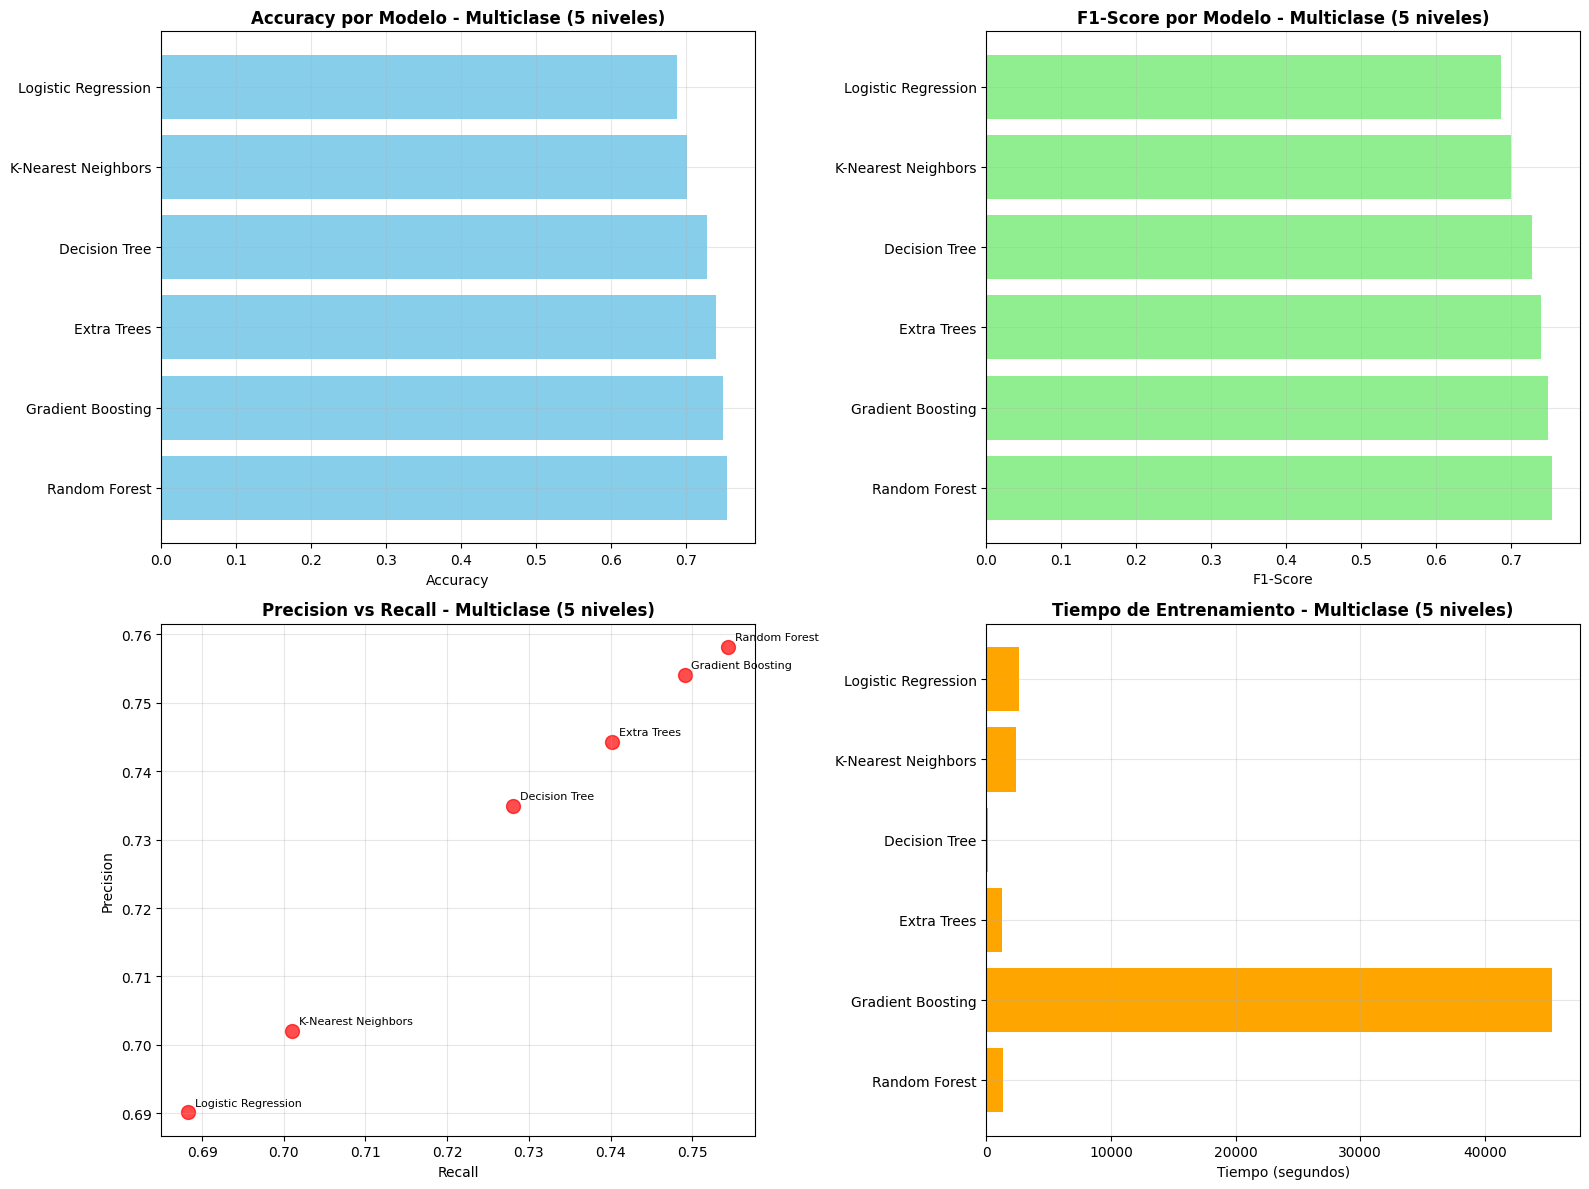

              precision    recall  f1-score   support

    Muy Baja     0.8376    0.9231    0.8783      7946
        Baja     0.6588    0.6194    0.6385      5836
       Media     0.5629    0.6521    0.6042      6918
        Alta     0.5639    0.5231    0.5427      6861
    Muy Alta     0.8001    0.6767    0.7332      6885

    accuracy                         0.6883     34446
   macro avg     0.6847    0.6789    0.6794     34446
weighted avg     0.6901    0.6883    0.6868     34446



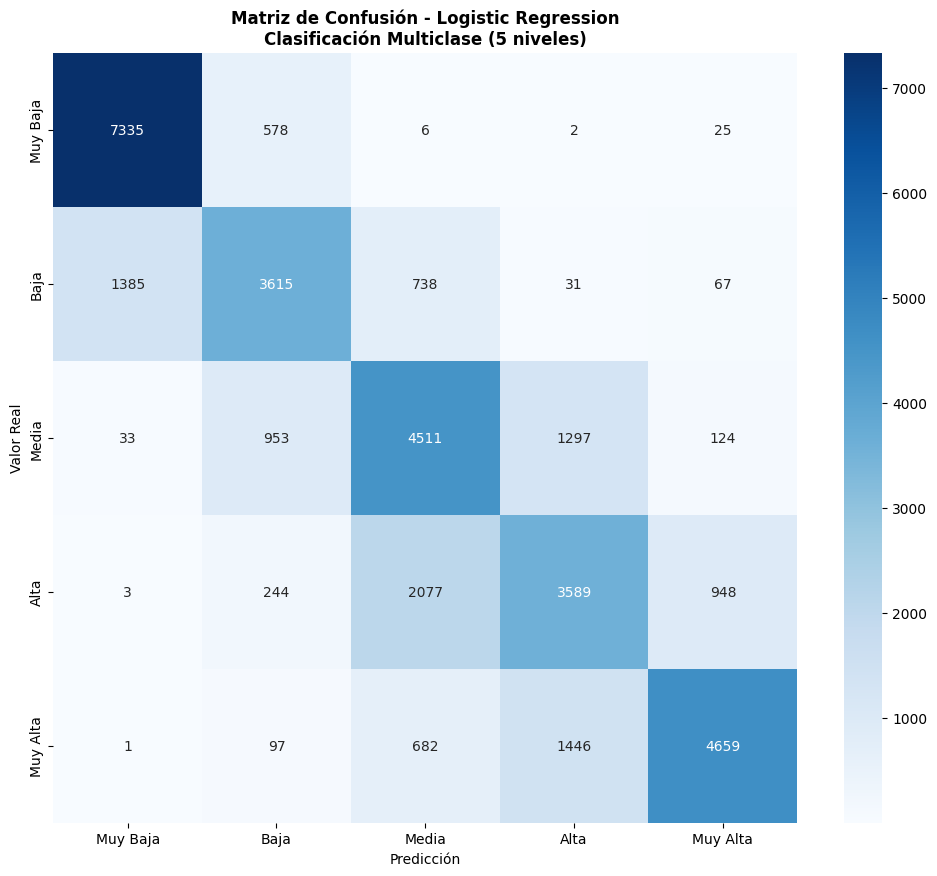

              precision    recall  f1-score   support

    Muy Baja     0.9325    0.9581    0.9451      7946
        Baja     0.7666    0.8191    0.7920      5836
       Media     0.6230    0.6946    0.6568      6918
        Alta     0.6046    0.5859    0.5951      6861
    Muy Alta     0.8385    0.6924    0.7585      6885

    accuracy                         0.7544     34446
   macro avg     0.7530    0.7500    0.7495     34446
weighted avg     0.7581    0.7544    0.7543     34446



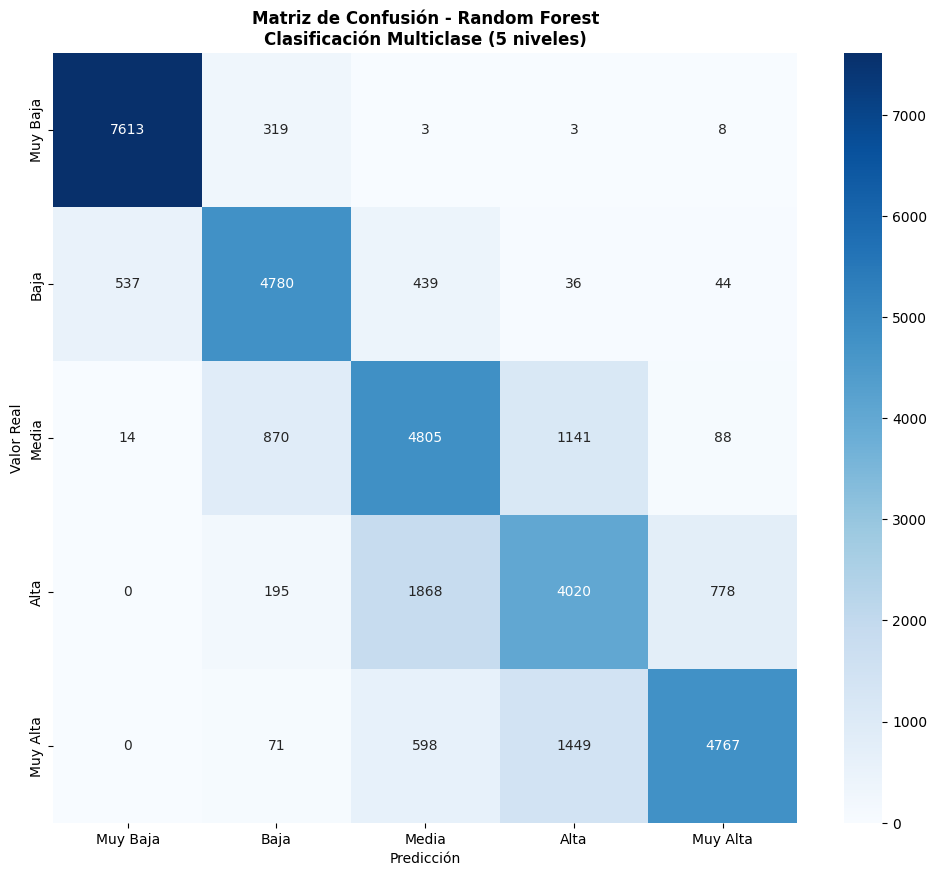

              precision    recall  f1-score   support

    Muy Baja     0.9353    0.9468    0.9410      7946
        Baja     0.7489    0.8220    0.7838      5836
       Media     0.6113    0.6886    0.6477      6918
        Alta     0.6058    0.5799    0.5926      6861
    Muy Alta     0.8407    0.6883    0.7569      6885

    accuracy                         0.7491     34446
   macro avg     0.7484    0.7451    0.7444     34446
weighted avg     0.7541    0.7491    0.7493     34446



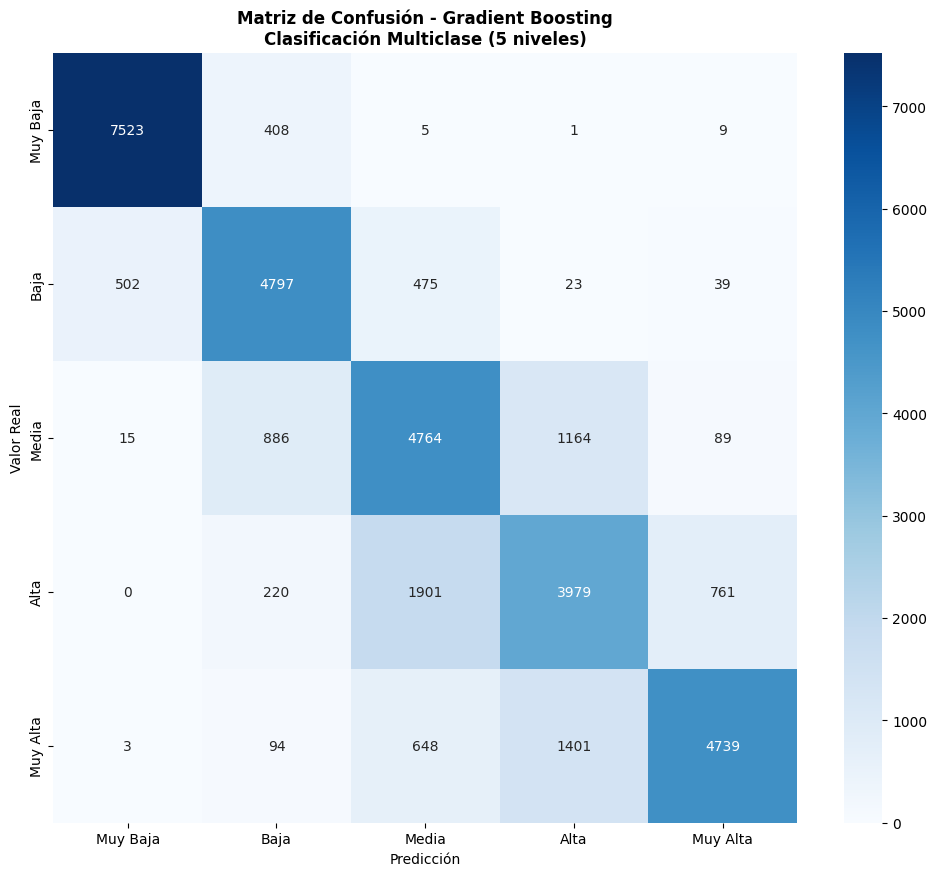

              precision    recall  f1-score   support

    Muy Baja     0.9228    0.9323    0.9275      7946
        Baja     0.7087    0.7942    0.7490      5836
       Media     0.5767    0.6785    0.6235      6918
        Alta     0.5971    0.5371    0.5655      6861
    Muy Alta     0.8369    0.6765    0.7482      6885

    accuracy                         0.7281     34446
   macro avg     0.7284    0.7237    0.7227     34446
weighted avg     0.7349    0.7281    0.7283     34446



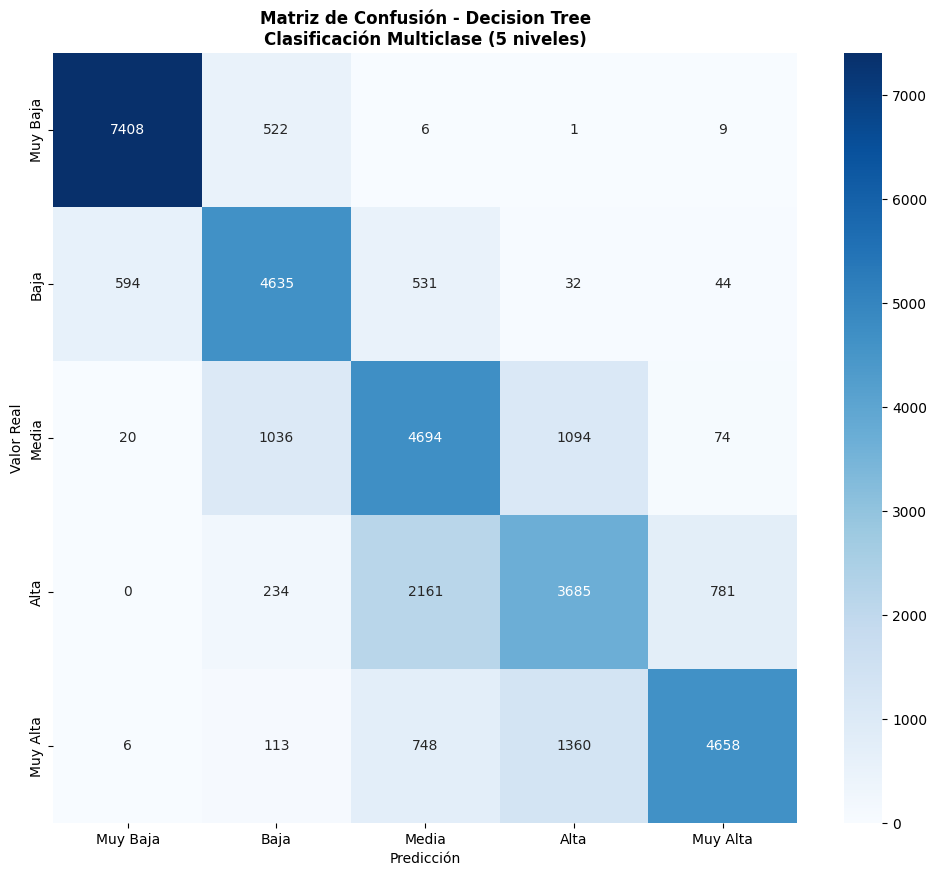

              precision    recall  f1-score   support

    Muy Baja     0.8848    0.9320    0.9078      7946
        Baja     0.7214    0.7406    0.7309      5836
       Media     0.5663    0.6503    0.6054      6918
        Alta     0.5466    0.5005    0.5225      6861
    Muy Alta     0.7658    0.6514    0.7040      6885

    accuracy                         0.7010     34446
   macro avg     0.6970    0.6950    0.6941     34446
weighted avg     0.7020    0.7010    0.6996     34446



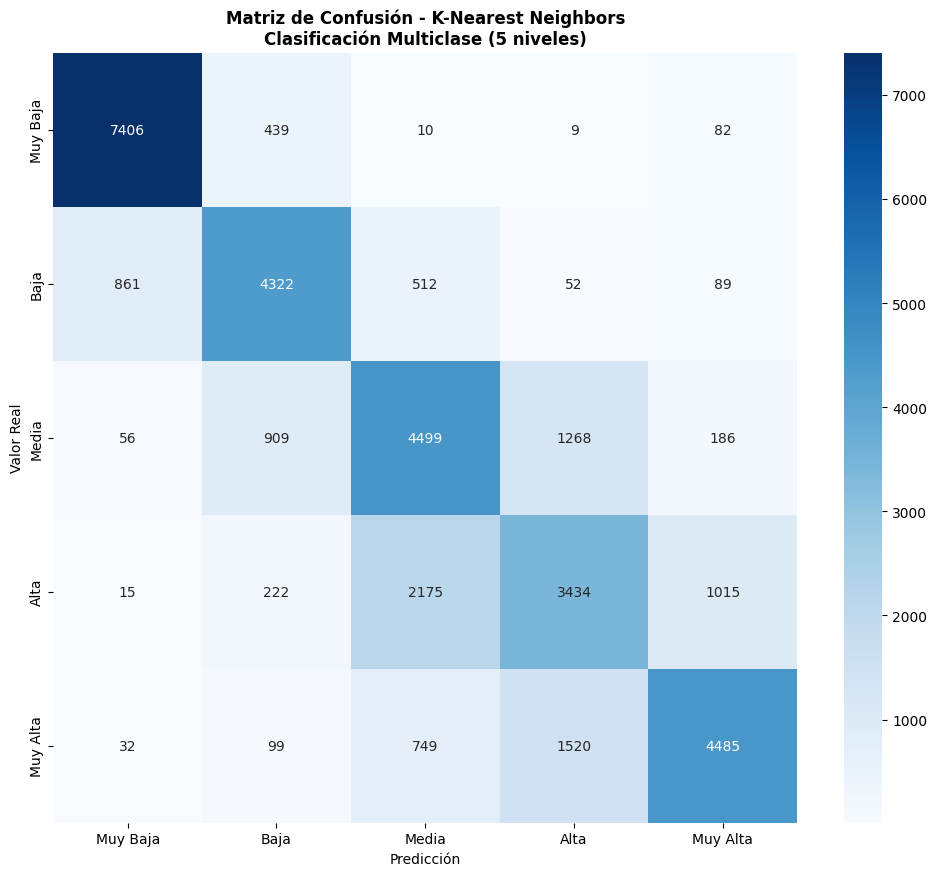

              precision    recall  f1-score   support

    Muy Baja     0.9094    0.9640    0.9359      7946
        Baja     0.7665    0.7772    0.7718      5836
       Media     0.6050    0.6833    0.6418      6918
        Alta     0.5856    0.5735    0.5795      6861
    Muy Alta     0.8327    0.6739    0.7450      6885

    accuracy                         0.7402     34446
   macro avg     0.7398    0.7344    0.7348     34446
weighted avg     0.7442    0.7402    0.7399     34446



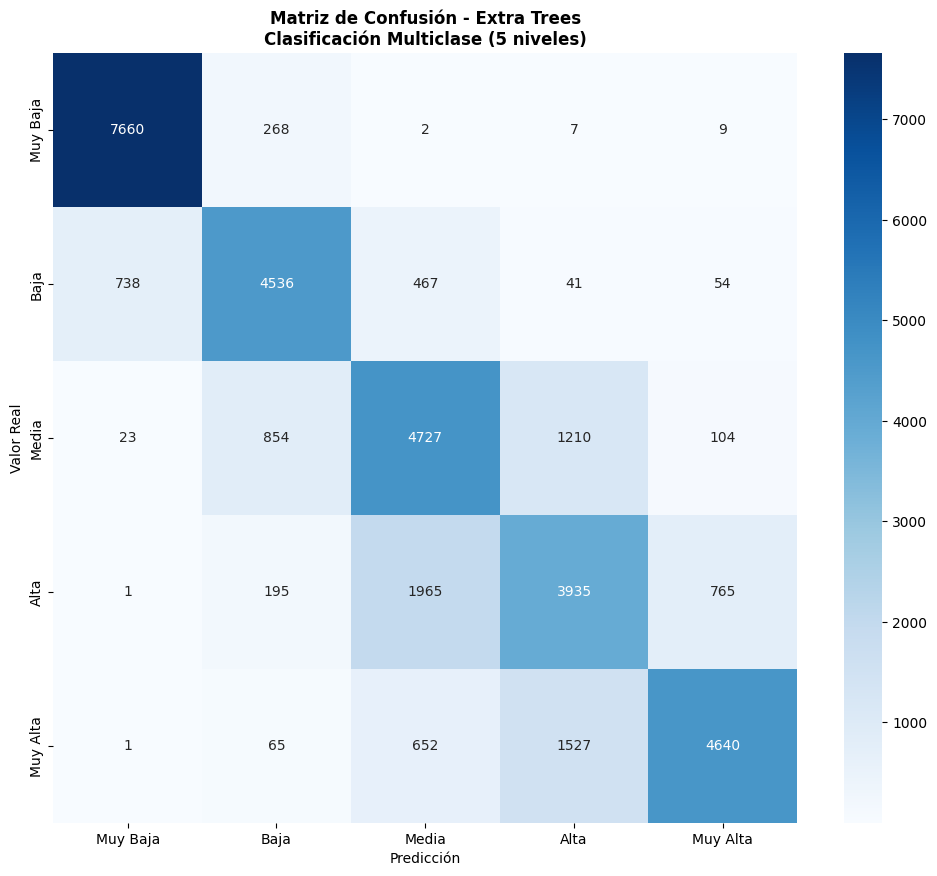


Clasificación multiclase (5 niveles) completada con 6 modelos


In [ ]:
multiclass5_grid_results = []

for model_name, model in base_models.items():
    try:
        if model_name == 'Logistic Regression' or model_name=='Naive Bayes':
            continue
      
        result = grid_search_model(
                model=model,
                param_grid=param_grids[model_name],
                X_train=X_train_multi5,
                X_test=X_test_multi5,
                y_train=y_train_multi5,
                y_test=y_test_multi5,
                model_name=model_name,
                _scaler=scaler2,
                pca=pca
            )
        multiclass5_grid_results.append(result)
    except Exception as e:
        print(f"Error con {model_name}: {str(e)}")

multiclass5_grid_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'CV Score': r['best_score'],
    'Tiempo (s)': r['training_time']
} for r in multiclass5_grid_results])

multiclass5_grid_df = multiclass5_grid_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print("RESULTADOS GRID SEARCH - CLASIFICACIÓN MULTICLASE (5 NIVELES):")
print(multiclass5_grid_df.round(4))
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(multiclass5_grid_df['Modelo'], multiclass5_grid_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (5 niveles)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(multiclass5_grid_df['Modelo'], multiclass5_grid_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (5 niveles)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(multiclass5_grid_df['Recall'], multiclass5_grid_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(multiclass5_grid_df['Modelo']):
    axes[1,0].annotate(txt, (multiclass5_grid_df['Recall'].iloc[i], multiclass5_grid_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (5 niveles)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(multiclass5_grid_df['Modelo'], multiclass5_grid_df['Tiempo (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (5 niveles)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(multiclass5_grid_results):
    plt.figure(figsize=(12, 10))
    cm = multiclass5_grid_results[i]['confusion_matrix']
    name_ = multiclass5_grid_results[i]['model_name']
    class_names_5 = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (5 niveles)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi5, multiclass5_grid_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()




print(f"\nClasificación multiclase (5 niveles) completada con {len(multiclass5_grid_results)} modelos")

In [ ]:
# ESTRATEGIAS ONE-VS-REST (OvR)

ovr_compatible_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    "xgboost":xgboost.XGBClassifier(random_state=42, objective='binary:logistic'),
    'Naive Bayes': GaussianNB(),
    'xgboost':xgboost.XGBClassifier(objective='binary:logistic',random_state=42)
}
p_grid={
    'xgboost':{
        'max_depth':[3,6,9],
        'n_estimators':[100,200,500],
        'objective':['binary:logistic']

    }
}

def evaluate_ovr_model(m, X_train, X_test, y_train, y_test, model_name, task_type,s,param_grid,cv=3,pca=pca):
    """Evalúa un modelo usando estrategia One-vs-Rest"""

    print(f"Entrenando OvR {model_name}...")
    
    grid_search = RandomizedSearchCV(
        n_iter=5,
        estimator=m,
        param_distributions=param_grid,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=0
    )
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    best_model = grid_search.best_estimator_
    print(grid_search.best_params_)
    start_time = time.time()
    X_test = s.transform(X_test)
    X_test = pca.transform(X_test)
    y_pred = best_model.predict(X_test)
    prediction_time = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results = {
        'model_name': f"OvR {model_name}",
        'strategy': 'OvR',
        'task_type': task_type,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'model_object': best_model,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
    }
    
    print(f"   Completado - Accuracy: {accuracy:.4f}, F1: {f1:.4f}")
    return results



ovr_multi3_results = []

for model_name, model in ovr_compatible_models.items():
    try:

        p = param_grids[model_name] if model_name!='xgboost' else p_grid['xgboost']
        new_p={f"estimator__{x}":y for x,y in p.items()}
        
        m = OneVsRestClassifier(model)
        result = evaluate_ovr_model(
            m=m,
            X_train=X_train_multi3,
            X_test=X_test_multi3,
            y_train=y_train_multi3,
            y_test=y_test_multi3,
            model_name=model_name,
            task_type='multiclass_3',
            s=scaler1,
            param_grid=new_p,
            pca=pca
        )
        ovr_multi3_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")


ovr_multi3_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovr_multi3_results])

ovr_multi3_df = ovr_multi3_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvR - MULTICLASE (3 NIVELES):")

print(ovr_multi3_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovr_multi3_df['Modelo'], ovr_multi3_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVR)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovr_multi3_df['Modelo'], ovr_multi3_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVR)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovr_multi3_df['Recall'], ovr_multi3_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovr_multi3_df['Modelo']):
    axes[1,0].annotate(txt, (ovr_multi3_df['Recall'].iloc[i], ovr_multi3_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVR)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovr_multi3_df['Modelo'], ovr_multi3_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVR)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovr_multi3_results):
    plt.figure(figsize=(12, 10))
    cm = ovr_multi3_results[i]['confusion_matrix']
    name_ = ovr_multi3_results[i]['model_name']
    class_names_5 = [ 'Baja', 'Media', 'Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVR)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi3, ovr_multi3_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()




Entrenando OvR Logistic Regression...
{'estimator__solver': 'saga', 'estimator__penalty': 'l2', 'estimator__C': 10.0}
   Completado - Accuracy: 0.8124, F1: 0.8110
Entrenando OvR Decision Tree...
{'estimator__min_samples_split': 2, 'estimator__max_depth': 10, 'estimator__criterion': 'gini'}
   Completado - Accuracy: 0.8386, F1: 0.8388
Entrenando OvR Random Forest...


In [ ]:

ovr_multi5_results = []

for model_name, model in ovr_compatible_models.items():
    try:
        p = param_grids[model_name] if model_name!='xgboost' else p_grid['xgboost']
        new_p={f"estimator__{x}":y for x,y in p.items()}
        m = OneVsRestClassifier(model)

        result = evaluate_ovr_model(
            m=m,
            X_train=X_train_multi5,
            X_test=X_test_multi5,
            y_train=y_train_multi5,
            y_test=y_test_multi5,
            model_name=model_name,
            task_type='multiclass_3',
            s=scaler2,
            param_grid=new_p,
            pca=pca
        )
        ovr_multi5_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")

ovr_multi5_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovr_multi5_results])

ovr_multi5_df = ovr_multi5_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvR - MULTICLASE (5 NIVELES):")
print(ovr_multi5_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovr_multi5_df['Modelo'], ovr_multi5_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVR-5)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovr_multi5_df['Modelo'], ovr_multi5_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVR-5)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovr_multi5_df['Recall'], ovr_multi5_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovr_multi5_df['Modelo']):
    axes[1,0].annotate(txt, (ovr_multi5_df['Recall'].iloc[i], ovr_multi5_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVR-5)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovr_multi5_df['Modelo'], ovr_multi5_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVR-5)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovr_multi5_results):
    plt.figure(figsize=(12, 10))
    cm = ovr_multi5_results[i]['confusion_matrix']
    name_ = ovr_multi5_results[i]['model_name']
    class_names_5 = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVR)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi5, ovr_multi5_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()



print(f"\nEstrategias OvR completadas")

In [ ]:
# ESTRATEGIAS ONE-VS-REST (OvO)

ovo_compatible_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'Naive Bayes': GaussianNB(),
    'xgboost':xgboost.XGBClassifier(objective=['binary:logistic'])
}


def evaluate_ovo_model(m, X_train, X_test, y_train, y_test, model_name, task_type,s,param_grid,cv=3,pca=pca):
    """Evalúa un modelo usando estrategia One-vs-Rest"""

    print(f"Entrenando OvO {model_name}...")
    
    grid_search = RandomizedSearchCV(
        n_iter=5,
        estimator=m,
        param_distributions=param_grid,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=0
    )
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    best_model = grid_search.best_estimator_
    print(grid_search.best_params_)
    start_time = time.time()
    X_test = s.transform(X_test)
    X_test = pca.transform(X_test)
    y_pred = best_model.predict(X_test)
    prediction_time = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results = {
        'model_name': f"OvR {model_name}",
        'strategy': 'OvR',
        'task_type': task_type,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'model_object': best_model,
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
    }
    
    print(f"   Completado - Accuracy: {accuracy:.4f}, F1: {f1:.4f}")
    return results


ovo_multi3_results = []

for model_name, model in ovr_compatible_models.items():
    try:
        p = param_grids[model_name] if model_name!='xgboost' else p_grid['xgboost']
        new_p={f"estimator__{x}":y for x,y in p.items()}
        m = OneVsOneClassifier(model)
        result = evaluate_ovo_model(
            m=m,
            X_train=X_train_multi3,
            X_test=X_test_multi3,
            y_train=y_train_multi3,
            y_test=y_test_multi3,
            model_name=model_name,
            task_type='multiclass_3',
            s=scaler1,
            param_grid=new_p,
            pca=pca
        )
        
        ovo_multi3_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")


ovo_multi3_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovo_multi3_results])

ovo_multi3_df = ovo_multi3_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvO - MULTICLASE (3 NIVELES):")

print(ovo_multi3_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovo_multi3_df['Modelo'], ovo_multi3_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVO)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovo_multi3_df['Modelo'], ovo_multi3_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVO)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovo_multi3_df['Recall'], ovo_multi3_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovo_multi3_df['Modelo']):
    axes[1,0].annotate(txt, (ovo_multi3_df['Recall'].iloc[i], ovo_multi3_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVO)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovo_multi3_df['Modelo'], ovo_multi3_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVO)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovo_multi3_results):
    plt.figure(figsize=(12, 10))
    cm = ovo_multi3_results[i]['confusion_matrix']
    name_ = ovo_multi3_results[i]['model_name']
    class_names_5 = ['Baja', 'Media', 'Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVO)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi3, ovo_multi3_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()



Entrenando OvO Logistic Regression...


KeyboardInterrupt: 

In [ ]:

ovo_multi5_results = []

for model_name, model in evaluate_ovo_model.items():
    try:
        p = param_grids[model_name] if model_name!='xgboost' else p_grid['xgboost']
        new_p={f"estimator__{x}":y for x,y in p.items()}
   
        result = evaluate_ovo_model(
            m=model,
            X_train=X_train_multi5,
            X_test=X_test_multi5,
            y_train=y_train_multi5,
            y_test=y_test_multi5,
            model_name=model_name,
            task_type='multiclass_5',
            s=scaler2,
            param_grid=new_p,
            pca=pca
        )
        ovo_multi5_results.append(result)
        
    except Exception as e:
        print(f"   ❌ Error con OvR {model_name}: {str(e)}")

ovo_multi5_df = pd.DataFrame([{
    'Modelo': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score'],
    'Tiempo Entrenamiento (s)': r['training_time'],
    'Tiempo Predicción (s)': r['prediction_time']
} for r in ovo_multi5_results])

ovo_multi5_df = ovo_multi5_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(f"\nRESULTADOS OvO - MULTICLASE (5 NIVELES):")
print(ovo_multi5_df.round(4))


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0,0].barh(ovo_multi5_df['Modelo'], ovo_multi5_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy por Modelo - Multiclase (OVO-5)', fontweight='bold')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)


axes[0,1].barh(ovo_multi5_df['Modelo'], ovo_multi5_df['F1-Score'], color='lightgreen')
axes[0,1].set_title('F1-Score por Modelo - Multiclase (OVO-5)', fontweight='bold')
axes[0,1].set_xlabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(ovo_multi5_df['Recall'], ovo_multi5_df['Precision'], 
                  s=100, alpha=0.7, c='red')
for i, txt in enumerate(ovo_multi5_df['Modelo']):
    axes[1,0].annotate(txt, (ovo_multi5_df['Recall'].iloc[i], ovo_multi5_df['Precision'].iloc[i]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1,0].set_title('Precision vs Recall - Multiclase (OVO-5)', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].barh(ovo_multi5_df['Modelo'], ovo_multi5_df['Tiempo Entrenamiento (s)'], color='orange')
axes[1,1].set_title('Tiempo de Entrenamiento - Multiclase (OVO-5)', fontweight='bold')
axes[1,1].set_xlabel('Tiempo (segundos)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



for i,_ in enumerate(ovo_multi5_results):
    plt.figure(figsize=(12, 10))
    cm = ovo_multi5_results[i]['confusion_matrix']
    name_ = ovo_multi5_results[i]['model_name']
    class_names_5 = ['Muy Baja', 'Baja', 'Media', 'Alta', 'Muy Alta']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_5,
                yticklabels=class_names_5)
    plt.title(f'Matriz de Confusión - {name_}\nClasificación Multiclase (OVO)', fontweight='bold')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    report = classification_report(y_test_multi5, ovo_multi5_results[i]['predictions'], 
                             target_names=class_names_5, digits=4)
    print(report)
    plt.show()



print(f"\nEstrategias OvO completadas")